In [ ]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.info

<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['director'] = df['director'].fillna('Not Available')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['duration'] = df['duration'].fillna('Unknown')

In [9]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [10]:
df['country'] = df['country'].str.strip().str.lower()
df['listed_in'] = df['listed_in'].str.strip().str.lower()
df['rating'] = df['rating'].str.strip().str.upper()

In [11]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [12]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month


In [13]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

In [14]:
df['duration_type'] = df['duration'].str.extract(r'(min|Season)')

In [15]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added       98
release_year      0
rating            0
duration          0
listed_in         0
description       0
year_added       98
month_added      98
duration_num      3
duration_type     3
dtype: int64

In [16]:
df['duration_num'] = df['duration_num'].fillna(0)
df['duration_type'] = df['duration_type'].fillna('Unknown')

In [17]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added       98
release_year      0
rating            0
duration          0
listed_in         0
description       0
year_added       98
month_added      98
duration_num      0
duration_type     0
dtype: int64

In [18]:
df['year_added'] = df['year_added'].fillna(0)
df['month_added'] = df['month_added'].fillna(0)

In [19]:
df = df.dropna(subset=['date_added'])

In [20]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added       0
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added       0
month_added      0
duration_num     0
duration_type    0
dtype: int64

In [21]:
df.to_csv("../data/netflix_cleaned_final.csv", index=False)

In [22]:
df.shape

(8709, 16)

# Milestone 2 - EDA & Feature Engineering

In [23]:
df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

content growth was slow before 2015
rapid increse observed frm 2016 
peak addtion occured in 2019
slight decline seen after 2019

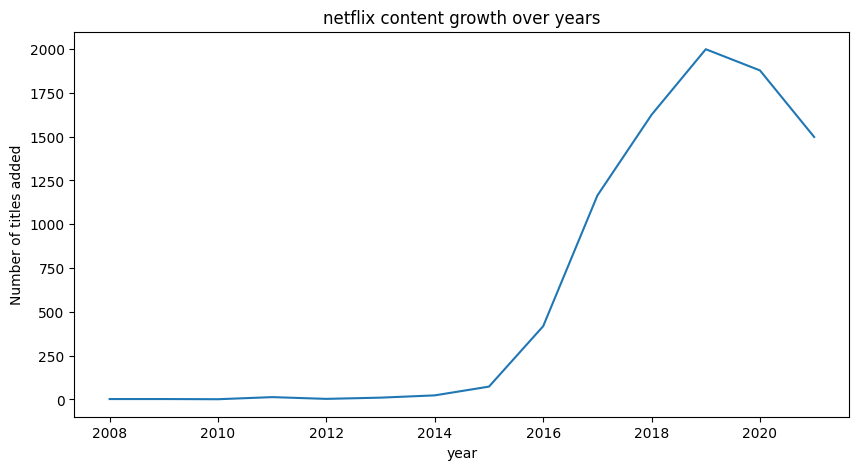

In [24]:
import matplotlib.pyplot as plt

yearly = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.plot(yearly.index,yearly.values)
plt.title("netflix content growth over years")
plt.xlabel("year")
plt.ylabel("Number of titles added")
plt.show()

In [25]:
df['type'].value_counts()

type
Movie      6131
TV Show    2578
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

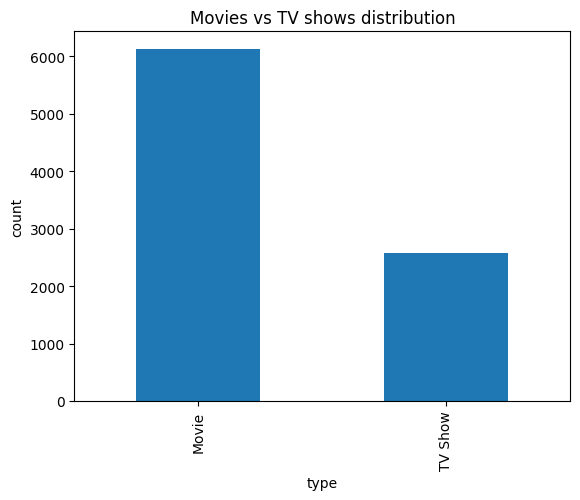

In [26]:
df['type'].value_counts().plot(kind = 'bar')
plt.title("Movies vs TV shows distribution")
plt.xlabel("type")
plt.ylabel("count")
plt.show

In [27]:
df['listed_in'] = df['listed_in'].str.split(', ')
genre_df = df.explode('listed_in')

genre_df['listed_in'].value_counts().head(10)

listed_in
international movies        2752
dramas                      2427
comedies                    1674
international tv shows      1328
documentaries                869
action & adventure           859
independent movies           756
tv dramas                    739
children & family movies     641
romantic movies              616
Name: count, dtype: int64

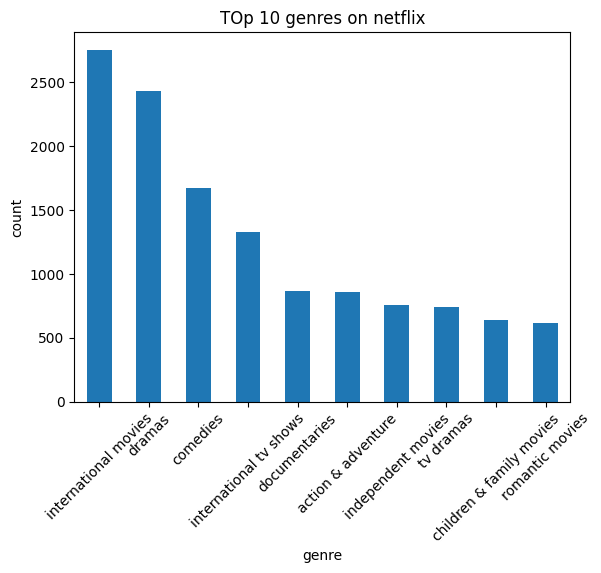

In [28]:
genre_df['listed_in'].value_counts().head(10).plot(kind='bar')
plt.title("TOp 10 genres on netflix")
plt.xlabel("genre")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.show()

In [29]:
df['country'] = df['country'].str.split(', ')
country_df = df.explode('country')

country_df['country'].value_counts().head(10)

country
united states     3642
india             1045
unknown            827
united kingdom     785
canada             432
france             389
japan              314
spain              228
south korea        226
germany            225
Name: count, dtype: int64

In [30]:
df[['duration_num','duration_type']].head()

,duration_num,duration_type
0,90.0,min
1,2.0,Season
2,1.0,Season
3,1.0,Season
4,2.0,Season


In [31]:
def categorize_length(row):
    if row['type'] == 'Movie':
        if row['duration_num'] < 60:
            return 'Short'
        elif row['duration_num'] <= 120:
            return 'Medium'
        else:
            return 'Long'
    else:
        return 'TV Show'
df['content_length_category'] = df.apply(categorize_length, axis=1)

In [32]:
df['content_length_category'].value_counts()

content_length_category
Medium     4528
TV Show    2578
Long       1142
Short       461
Name: count, dtype: int64

- Majority of movies fall under the 'Medium' category (60–120 mins).
- TV Shows form a significant portion of the platform.
- Long-duration movies are fewer compared to medium-length films.
- Short movies represent a small portion of the catalog.

In [33]:
df['is_original'] = df['description'].str.contains("Netflix", case=False, na=False)
df['is_original'].value_counts()

is_original
False    8700
True        9
Name: count, dtype: int64

# Original vs Licensed Feature (Heuristic Based)

- The feature was derived by checking the presence of the keyword "Netflix" in the description.
- Only 9 titles were identified as Netflix Originals.
- This method is not fully reliable, as many Originals may not explicitly mention "Netflix" in the description.
- Therefore, this feature should be treated as an approximate indicator.

In [43]:
import pandas as pd

df = pd.read_csv("../data/netflix_cleaned.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,"September 25, 2021",2020,PG-13,90 min,documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,"September 24, 2021",2021,TV-MA,2 Seasons,"international tv shows, tv dramas, tv mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,"September 24, 2021",2021,TV-MA,1 Season,"crime tv shows, international tv shows, tv act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Not Available,Not Available,unknown,"September 24, 2021",2021,TV-MA,1 Season,"docuseries, reality tv","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,"September 24, 2021",2021,TV-MA,2 Seasons,"international tv shows, romantic tv shows, tv ...",In a city of coaching centers known to train I...


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8807 non-null   str  
 9   duration      8807 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [45]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

In [47]:
from sklearn.preprocessing import LabelEncoder

le_rating = LabelEncoder()
df['rating_encoded'] = le_rating.fit_transform(df['rating'])

In [48]:
le_genre = LabelEncoder()
df['genre_encoded'] = le_genre.fit_transform(df['listed_in'])

In [49]:
features = df[['duration_num','rating_encoded','genre_encoded']]

features.head()

,duration_num,rating_encoded,genre_encoded
0,90.0,8,274
1,2.0,12,415
2,1.0,12,242
3,1.0,12,297
4,2.0,12,394


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

In [51]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

df['cluster'] = kmeans.fit_predict(X_scaled)

df[['title','cluster']].head()

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [52]:
features.isnull().sum()

duration_num      3
rating_encoded    0
genre_encoded     0
dtype: int64

In [53]:
features = features.fillna(features.median())

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

In [55]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

df['cluster'] = kmeans.fit_predict(X_scaled)

In [56]:
df[['title','cluster']].head()

,title,cluster
0,Dick Johnson Is Dead,3
1,Blood & Water,4
2,Ganglands,0
3,Jailbirds New Orleans,0
4,Kota Factory,4


In [57]:
df.groupby('cluster')['duration_num'].mean()

cluster
0      7.082942
1    108.886154
2    100.156031
3    107.949905
4     13.965603
Name: duration_num, dtype: float64

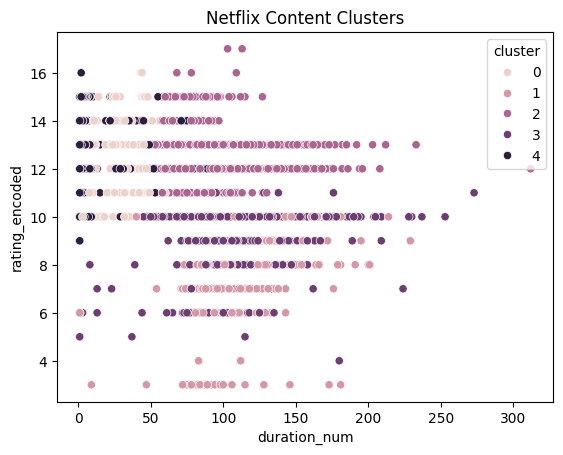

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x=df['duration_num'],
    y=df['rating_encoded'],
    hue=df['cluster']
)

plt.title("Netflix Content Clusters")
plt.show()

In [59]:
df['type_encoded'] = df['type'].map({'Movie':0,'TV Show':1})

In [60]:
X = df[['duration_num','rating_encoded','genre_encoded']]
y = df['type_encoded']

In [61]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [62]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [63]:
y_pred = model.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9994324631101021


In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



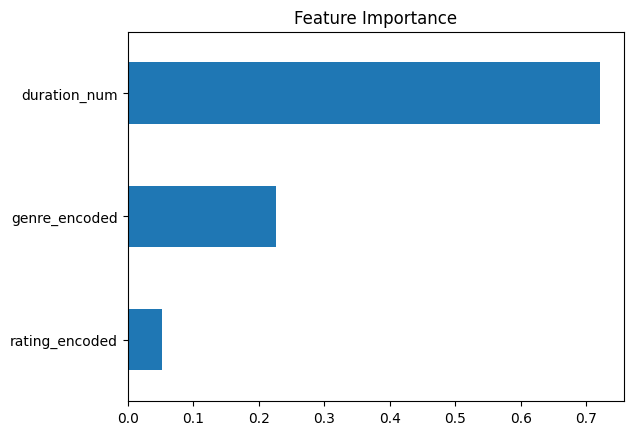

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X.columns
)

feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()